<a href="https://colab.research.google.com/github/shreyoshi2304/Neurobiology-I/blob/main/Exploring_attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

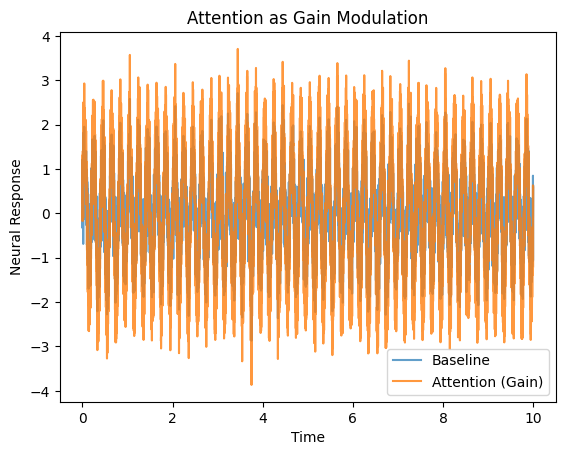

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# Time
T = 10
dt = 0.001
t = np.arange(0, T, dt)

# Stimulus (signal)
signal = np.sin(2 * np.pi * 5 * t)

# Noise
noise = np.random.normal(0, 0.5, len(t))

# Baseline neural response
baseline = signal + noise

# Attention = multiplicative gain
gain = 2.0
attended = gain * signal + noise

# Plot
plt.figure()
plt.plot(t, baseline, label="Baseline", alpha=0.7)
plt.plot(t, attended, label="Attention (Gain)", alpha=0.8)
plt.legend()
plt.xlabel("Time")
plt.ylabel("Neural Response")
plt.title("Attention as Gain Modulation")
plt.show()

In [2]:
def compute_snr(signal, noise):
    return np.var(signal) / np.var(noise)

print("Baseline SNR:", compute_snr(signal, noise))
print("Attention SNR:", compute_snr(gain * signal, noise))

Baseline SNR: 2.0507184184805887
Attention SNR: 8.202873673922355


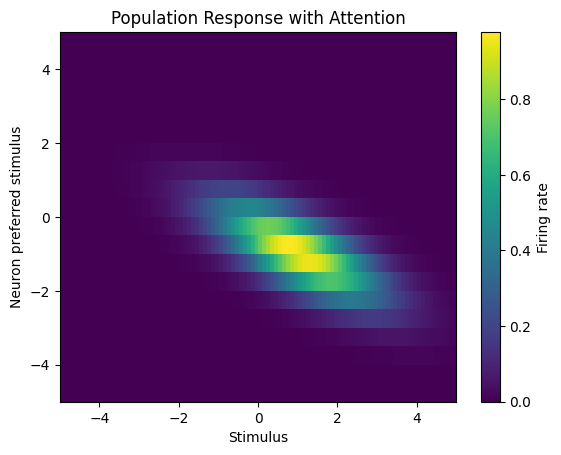

In [3]:
# Stimulus space
stimulus_space = np.linspace(-5, 5, 100)

# Neuron preferred stimuli
preferred = np.linspace(-5, 5, 20)

def tuning_curve(x, mu, sigma=1.0):
    return np.exp(-(x - mu)**2 / (2*sigma**2))

# Population response
responses = np.array([
    tuning_curve(stimulus_space, mu) for mu in preferred
])

# Attention: amplify neurons near target stimulus
target = 1.0
attention_profile = np.exp(-(preferred - target)**2 / 2)

attended_responses = responses * attention_profile[:, None]

# Plot population
plt.figure()
plt.imshow(attended_responses, aspect='auto', extent=[-5,5,-5,5])
plt.colorbar(label="Firing rate")
plt.xlabel("Stimulus")
plt.ylabel("Neuron preferred stimulus")
plt.title("Population Response with Attention")
plt.show()

In [4]:
def softmax(x, beta=2.0):
    exp_x = np.exp(beta * x)
    return exp_x / np.sum(exp_x)

# Example inputs (two stimuli)
inputs = np.array([1.0, 0.8, 0.3])

# With attention bias
attention_bias = np.array([1.5, 1.0, 1.0])
biased_inputs = inputs * attention_bias

output = softmax(biased_inputs)

print("Inputs:", inputs)
print("After attention:", biased_inputs)
print("Competitive output:", output)

Inputs: [1.  0.8 0.3]
After attention: [1.5 0.8 0.3]
Competitive output: [0.74776703 0.18439708 0.06783589]


In [5]:
def competitive_dynamics(inputs, steps=100, dt=0.1):
    N = len(inputs)
    x = np.random.rand(N)

    for _ in range(steps):
        inhibition = np.sum(x)
        dx = inputs - x - 0.5 * inhibition
        x += dt * dx
        x = np.maximum(x, 0)

    return x

inputs = np.array([1.0, 0.9, 0.5])
final_state = competitive_dynamics(inputs)

print("Final activity:", final_state)

Final activity: [0.51998817 0.41999896 0.02001287]


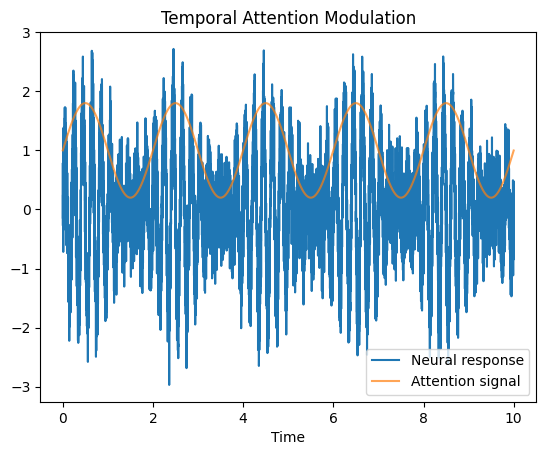

In [6]:
# Time-varying attention
attention_signal = 1 + 0.8 * np.sin(2 * np.pi * 0.5 * t)

# Input signal
signal = np.sin(2 * np.pi * 5 * t)

# Noise
noise = np.random.normal(0, 0.4, len(t))

# Dynamic attention-modulated response
response = attention_signal * signal + noise

# Plot
plt.figure()
plt.plot(t, response, label="Neural response")
plt.plot(t, attention_signal, label="Attention signal", alpha=0.7)
plt.legend()
plt.title("Temporal Attention Modulation")
plt.xlabel("Time")
plt.show()

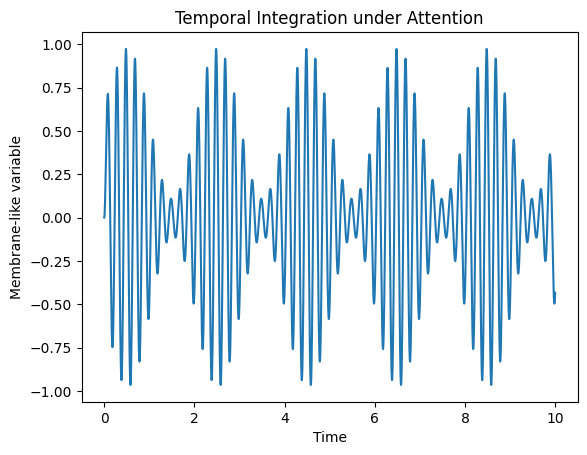

In [7]:
# Leaky integrator neuron with attention
tau = 0.05
V = np.zeros(len(t))

for i in range(len(t)-1):
    input_signal = attention_signal[i] * signal[i]
    dV = (-V[i] + input_signal) / tau
    V[i+1] = V[i] + dt * dV

plt.figure()
plt.plot(t, V)
plt.title("Temporal Integration under Attention")
plt.xlabel("Time")
plt.ylabel("Membrane-like variable")
plt.show()